In [7]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from scipy import stats

df = pd.read_csv('../data/MX_videos_limpio.csv')

In [8]:
top_3_categories_names = ['Entertainment', 'Sports', 'Music']
df_top3 = df[df['category_name'].isin(top_3_categories_names)]

samples = [df_top3['views'][df_top3['category_name'] == cat] for cat in top_3_categories_names]

statistic, p_value = stats.kruskal(*samples)

print(f"Resultado de la prueba Kruskal-Wallis (comparando Vistas en Top 3 Categorías):")
print(f"P-valor: {p_value:.4g}")
print("\nCONCLUSIÓN 1: El p-valor es prácticamente cero, lo que confirma con certeza estadística que SÍ existe una diferencia real en el rendimiento entre estas categorías.")

Resultado de la prueba Kruskal-Wallis (comparando Vistas en Top 3 Categorías):
P-valor: 7.301e-116

CONCLUSIÓN 1: El p-valor es prácticamente cero, lo que confirma con certeza estadística que SÍ existe una diferencia real en el rendimiento entre estas categorías.


In [11]:
avg_views_music = df[df['category_name'] == 'Music']['views'].mean()

avg_views_others = df[df['category_name'] != 'Music']['views'].mean()

difference = (avg_views_music / avg_views_others) - 1

print(f"Rendimiento Promedio de Vistas:")
print(f"- Música: {avg_views_music:,.0f} vistas en promedio.")
print(f"- Resto de Categorías: {avg_views_others:,.0f} vistas en promedio.")
print(f"\nCONCLUSIÓN 2: Un video de 'Música' en tendencia tiene, en promedio, un {difference:.0%} más de vistas que un video de cualquier otra categoría. La dominancia es masiva.")

Rendimiento Promedio de Vistas:
- Música: 1,233,970 vistas en promedio.
- Resto de Categorías: 261,326 vistas en promedio.

CONCLUSIÓN 2: Un video de 'Música' en tendencia tiene, en promedio, un 372% más de vistas que un video de cualquier otra categoría. La dominancia es masiva.


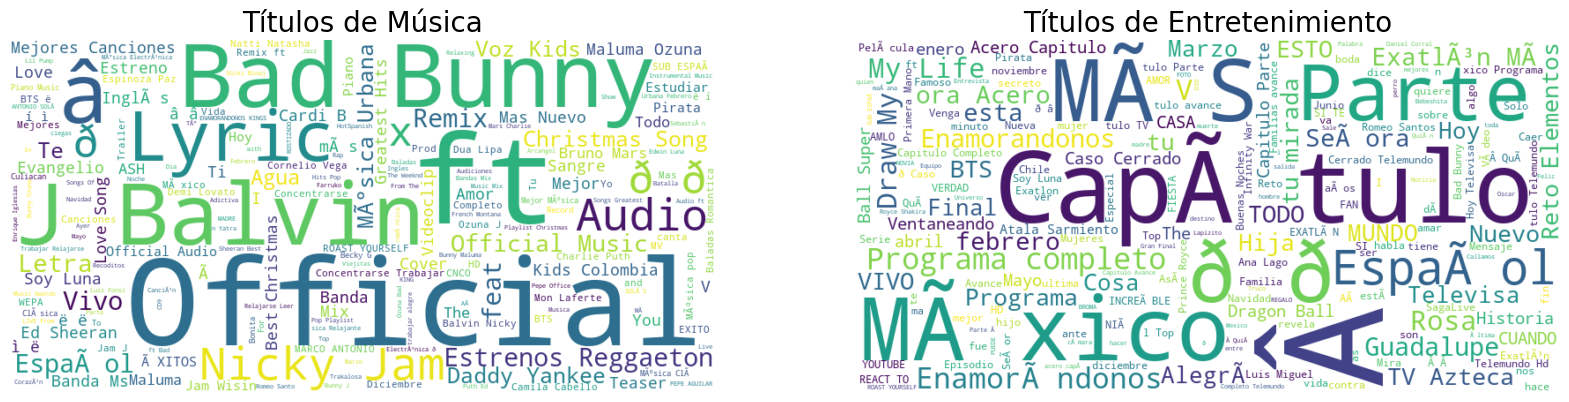


CONCLUSIÓN 3: Sí, el lenguaje es drásticamente diferente. Los títulos de 'Música' están dominados por nombres de artistas (ej. 'Maluma', 'Ozuna') y formatos ('Audio', 'Lyric'). Los de 'Entretenimiento' se centran en formatos de reality y talk shows ('Capítulo', 'Reto', 'Enamorándonos').


In [10]:


stopwords_es = set(['de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'por', 'con', 'no', 'una', 'su', 'para', 'es', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'he', 'mi', 'sin', 'qué', 'me', 'este', 'ya', 'o', 'se', 'ha', 'que', 'Video', 'Oficial'])

text_music = ' '.join(df[df['category_name'] == 'Music']['title'].dropna())
wc_music = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_es).generate(text_music)

text_entertainment = ' '.join(df[df['category_name'] == 'Entertainment']['title'].dropna())
wc_entertainment = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_es).generate(text_entertainment)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(wc_music, interpolation='bilinear')
axes[0].set_title('Títulos de Música', fontsize=20)
axes[0].axis('off')

axes[1].imshow(wc_entertainment, interpolation='bilinear')
axes[1].set_title('Títulos de Entretenimiento', fontsize=20)
axes[1].axis('off')
plt.show()

print("\nCONCLUSIÓN 3: Sí, el lenguaje es drásticamente diferente. Los títulos de 'Música' están dominados por nombres de artistas (ej. 'Maluma', 'Ozuna') y formatos ('Audio', 'Lyric'). Los de 'Entretenimiento' se centran en formatos de reality y talk shows ('Capítulo', 'Reto', 'Enamorándonos').")